In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

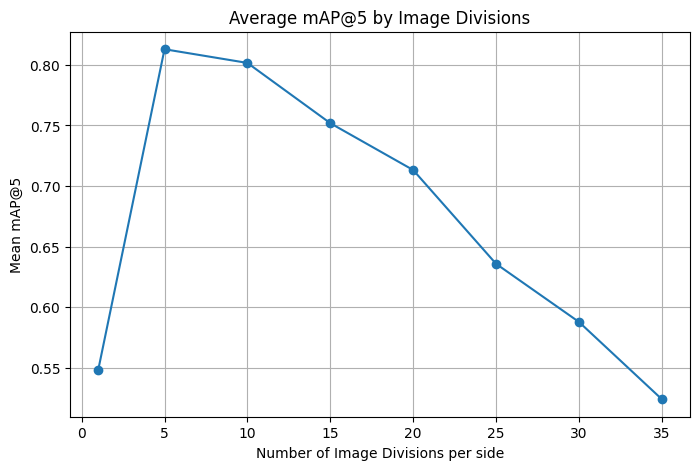

,hier_level,mAP@5
0,1,0.548356
1,5,0.812801
2,10,0.801505
3,15,0.751829
4,20,0.713218
5,25,0.635903
6,30,0.587986
7,35,0.524282


In [2]:
# Load CSV
df = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_big.csv")

# Extract the number after "hier" in the descriptor column
df['hier_level'] = df['descriptor'].apply(lambda x: int(re.search(r"hier(\d+)", x).group(1)) if re.search(r"hier(\d+)", x) else None)

# Group by hier_level and compute mean of "mAP@5"
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(mean_scores['hier_level'], mean_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Mean mAP@5")
plt.title("Average mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

mean_scores

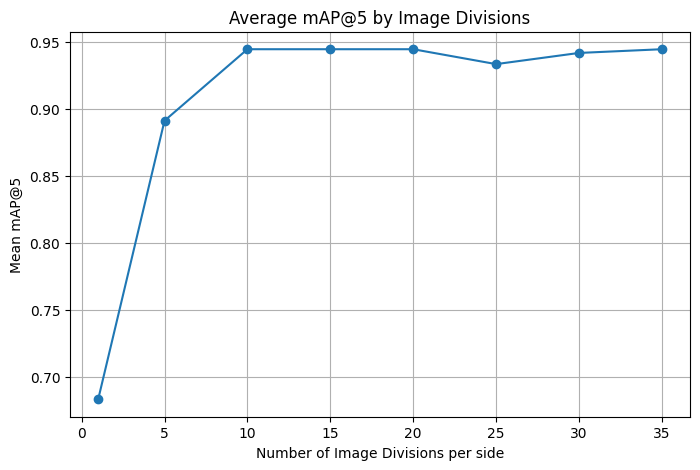

,hier_level,mAP@5
0,1,0.683333
1,5,0.891111
2,10,0.944444
3,15,0.944444
4,20,0.944444
5,25,0.933333
6,30,0.941667
7,35,0.944444


In [3]:
# Group by hier_level and compute mean of "mAP@5"
max_scores = df.groupby('hier_level')['mAP@5'].max().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(max_scores['hier_level'], max_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Mean mAP@5")
plt.title("Average mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

max_scores

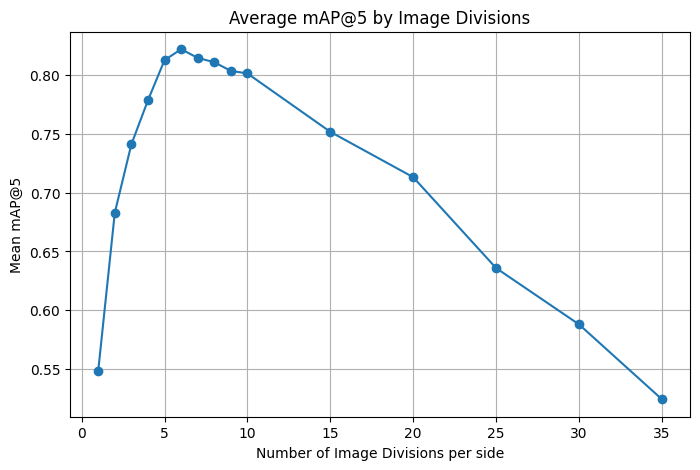

    hier_level     mAP@5
0            1  0.548356
1            2  0.682940
2            3  0.741134
3            4  0.778634
4            5  0.812801
5            6  0.822106
6            7  0.814769
7            8  0.811019
8            9  0.803704
9           10  0.801505
10          15  0.751829
11          20  0.713218
12          25  0.635903
13          30  0.587986
14          35  0.524282


In [4]:
# --- Load and merge CSV files vertically ---
df1 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_big.csv")
df2 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_small.csv")

# Merge vertically (stack rows)
df = pd.concat([df1, df2], ignore_index=True)

# --- Extract the number after "hier" in the descriptor column ---
df['hier_level'] = df['descriptor'].apply(
    lambda x: int(re.search(r"hier(\d+)", x).group(1)) if re.search(r"hier(\d+)", x) else None
)

# --- Group by hier_level and compute mean of "mAP@5" ---
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(mean_scores['hier_level'], mean_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Mean mAP@5")
plt.title("Average mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

# Display the first few results
print(mean_scores)

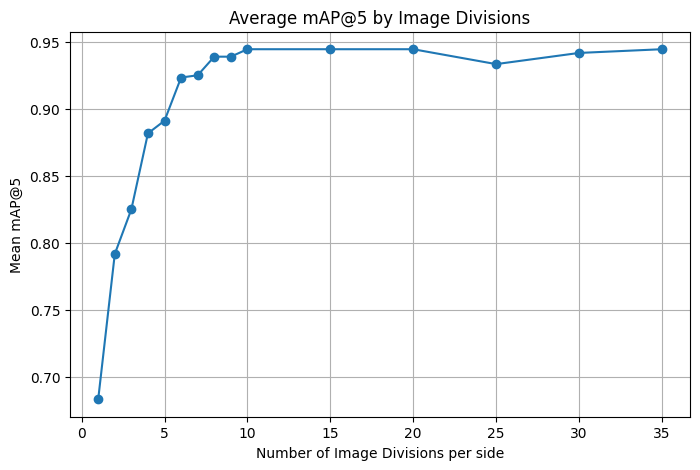

    hier_level     mAP@5
0            1  0.683333
1            2  0.791667
2            3  0.825000
3            4  0.881667
4            5  0.891111
5            6  0.923333
6            7  0.925000
7            8  0.938889
8            9  0.938889
9           10  0.944444
10          15  0.944444
11          20  0.944444
12          25  0.933333
13          30  0.941667
14          35  0.944444


In [5]:
# --- Group by hier_level and compute max of "mAP@5" ---
max_scores = df.groupby('hier_level')['mAP@5'].max().reset_index()

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(max_scores['hier_level'], max_scores['mAP@5'], marker='o')
plt.xlabel("Number of Image Divisions per side")
plt.ylabel("Mean mAP@5")
plt.title("Average mAP@5 by Image Divisions")
plt.grid(True)
plt.show()

# Display the first few results
print(max_scores)

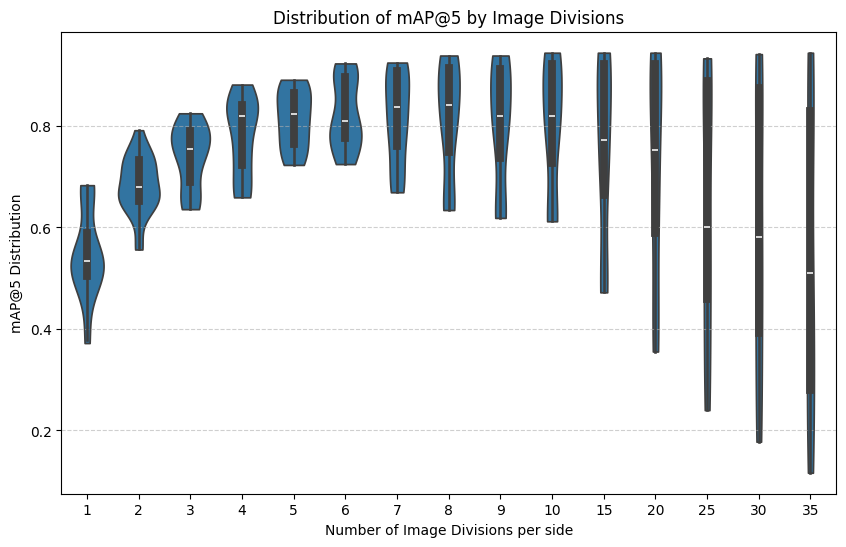

    hier_level     mAP@5
0            1  0.548356
1            2  0.682940
2            3  0.741134
3            4  0.778634
4            5  0.812801
5            6  0.822106
6            7  0.814769
7            8  0.811019
8            9  0.803704
9           10  0.801505
10          15  0.751829
11          20  0.713218
12          25  0.635903
13          30  0.587986
14          35  0.524282


In [6]:
# --- Load and merge CSV files vertically ---
df1 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_big.csv")
df2 = pd.read_csv("/home/gerardasbert/Desktop/Master/C1/projecte/Team3/results_csv/dev_scores_hierarchical_small.csv")

# Merge vertically (stack rows)
df = pd.concat([df1, df2], ignore_index=True)

# --- Extract the number after "hier" in the descriptor column ---
df['hier_level'] = df['descriptor'].apply(
    lambda x: int(re.search(r"hier(\d+)", x).group(1)) if re.search(r"hier(\d+)", x) else None
)

# --- Drop NaN hier_levels (just in case) ---
df = df.dropna(subset=['hier_level'])

# --- Violin plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='hier_level', y='mAP@5', data=df, inner='box', cut=0)

plt.xlabel("Number of Image Divisions per side")
plt.ylabel("mAP@5 Distribution")
plt.title("Distribution of mAP@5 by Image Divisions")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

# Display mean values for reference
mean_scores = df.groupby('hier_level')['mAP@5'].mean().reset_index()
print(mean_scores)